In [1]:
# 最后一种重构方式：U-NET
# LOSS = MLE + 梯度平滑性的正则项
# 1. Import necessary packages
import os
import numpy as np
from PIL import Image
import pyvista as pv
from torch.utils.data import Dataset , dataloader

c:\Users\lyn20\anaconda3\envs\cellpose\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
folder_path = r'E:\working_stack\WT10 0.5mm_72h'
image_set = []

# 获取文件夹中所有 png 图片，按文件名排序
file_list = sorted(f for f in os.listdir(folder_path) if f.lower().endswith('.png'))

for file_name in file_list:
    img = np.array(Image.open(os.path.join(folder_path, file_name)))
    image_set.append(img)

print(f'共导入 {len(image_set)} 张图片')
print(f'第一张图片尺寸: {image_set[0].shape}')

共导入 59 张图片
第一张图片尺寸: (3571, 5113, 3)


In [3]:
# 构造U-NET的过程自带归一化，加上U-NET并非抽取整个图片，只是用卷积核给局部图片照相，所以不再warp图片至同一个尺寸
# —— 空间开销优化（图片约 3000×5000，共 59 张）——
# 1. __init__ 只保存 uint8 数组的引用和单通道视图，零拷贝：
#    若把全图转成 float32 存储，59 张约需 3.5 GB；保持 uint8 仅约 0.9 GB
# 2. "先裁剪、后归一化"：__getitem__ 只把 1024×1024 的小块转成 float32，
#    每个样本临时开销仅十几 MB，用完即释放
# 3. "每张图裁 20 块"用索引映射实现（len = 57×20 = 1140），不预生成切片
#    —— 预生成 1140×3 块 uint8 切片也要约 3.4 GB，映射法开销为 0
import numpy as np
import torch


class BrainSliceDataset(Dataset):

    def __init__(self, image_set, crop_size=512, crops_per_image=20, seed=None):
        """
        image_set: cell 2 导入的、按切片顺序排列的 numpy 数组列表
        crop_size: 随机裁剪的边长（远大于 256×256 的最大卷积核，留足下采样余量）
        crops_per_image: 每个三元组 (i, i+1, i+2) 每轮随机裁剪的次数
        seed: 固定随机种子。
              None → 每次取样位置重新随机（相当于无限数据增强，适合训练集）
              整数 → 裁剪位置由 (seed, idx) 确定性推导：同一 idx 永远得到同一裁剪，
                     且与访问顺序、DataLoader 的 num_workers 均无关（可复现，适合验证/测试）
        """
        self.crop_size = crop_size
        self.crops_per_image = crops_per_image
        self.seed = seed

        # 只存引用，不复制内存
        # 凑巧原始数据只有 R 一个通道有效，取 arr[..., 0] 即灰度（视图，零拷贝）
        self.slices = []
        for img in image_set:
            arr = np.asarray(img)
            if arr.ndim == 3:
                arr = arr[..., 0]
            self.slices.append(arr)

    def __len__(self):
        """
        57 个三元组 × 每组 20 次随机裁剪 = 每轮 1140 个训练样本
        """
        return (len(self.slices) - 2) * self.crops_per_image

    def _crop_pad(self, arr, top, left):
        """
        从 arr 的 (top, left) 处裁出 crop_size×crop_size 的窗口；
        窗口越出图像边界的部分填充灰度值 0（用于两张图片尺寸不一致的情形）
        """
        size = self.crop_size
        H, W = arr.shape
        ch = min(size, max(0, H - top))     # 窗口内实际可取到的行数
        cw = min(size, max(0, W - left))    # 窗口内实际可取到的列数
        if ch > 0 and cw > 0:
            patch = arr[top:top + ch, left:left + cw]      # 视图，零拷贝
            if ch < size or cw < size:                     # 越界才真正填充
                patch = np.pad(patch, ((0, size - ch), (0, size - cw)),
                               mode='constant', constant_values=0)
        else:                                              # 窗口完全落在图外
            patch = np.zeros((size, size), dtype=arr.dtype)
        return patch

    def __getitem__(self, idx):
        """
        输入：样本索引 idx，其中 i = idx // 20 为图片三元组索引。
              用 i 与 i+2 两张图片相同位置的局部切片作为神经网络输入，推导出 i+1 的形状
        输出：训练图片 x (2, 1024, 1024) 与 ground truth y (1, 1024, 1024)，
              均归一化到 [0, 1]
        """
        i = idx // self.crops_per_image
        prev_arr = self.slices[i]
        target_arr = self.slices[i + 1]
        next_arr = self.slices[i + 2]

        # 裁剪位置只采样一次、三张图共用 —— 保证 idx 与 idx+2 的裁剪位置相同；
        # 采样范围取三张图的最大高宽，尺寸较小的图在 _crop_pad 中补 0
        size = self.crop_size
        max_h = max(prev_arr.shape[0], target_arr.shape[0], next_arr.shape[0])
        max_w = max(prev_arr.shape[1], target_arr.shape[1], next_arr.shape[1])
        if self.seed is None:
            # 不固定种子：每次取样位置重新随机
            top = np.random.randint(0, max(1, max_h - size + 1))
            left = np.random.randint(0, max(1, max_w - size + 1))
        else:
            # 固定种子：由 (seed, idx) 派生独立 RNG，裁剪位置可复现
            rng = np.random.default_rng([self.seed, idx])
            top = rng.integers(0, max(1, max_h - size + 1))
            left = rng.integers(0, max(1, max_w - size + 1))

        # 先在 uint8 上裁剪，再只对小块做 float32 归一化（div_ 原地操作，省一次内存分配）
        x = torch.stack([
            torch.from_numpy(self._crop_pad(prev_arr, top, left)),
            torch.from_numpy(self._crop_pad(next_arr, top, left)),
        ]).float().div_(255.0)                                   # (2, 1024, 1024)

        y = torch.from_numpy(self._crop_pad(target_arr, top, left)) \
              .float().div_(255.0).unsqueeze(0)                  # (1, 1024, 1024)

        return x, y

In [4]:
# 端到端验证：构造数据集并取一个样本
dataset = BrainSliceDataset(image_set)  #image_set:上面已经建立好的59张图片（实际用了57张）的有序列表
print(f'数据集长度: {len(dataset)}')   # (59-2) × 20 = 1140

x, y = dataset[0]
print(f'x 形状: {x.shape}, 取值范围: [{x.min():.3f}, {x.max():.3f}]')
print(f'y 形状: {y.shape}, 取值范围: [{y.min():.3f}, {y.max():.3f}]')

# 验证固定种子：同一 idx 两次取样结果完全一致（可复现）
dataset_fixed = BrainSliceDataset(image_set, seed=42)
xa, _ = dataset_fixed[0]
xb, _ = dataset_fixed[0]
print(f'固定种子下两次取样完全一致: {torch.equal(xa, xb)}')

# 不固定种子时两次取样（大概率）不同 —— 相当于数据增强
xc, _ = dataset[0]
print(f'随机模式下两次取样不同: {not torch.equal(xa, xc)}')

数据集长度: 1140
x 形状: torch.Size([2, 512, 512]), 取值范围: [0.000, 1.000]
y 形状: torch.Size([1, 512, 512]), 取值范围: [0.000, 1.000]
固定种子下两次取样完全一致: True
随机模式下两次取样不同: True


In [5]:
import torch.nn as nn
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [6]:
# —— nn.Conv2d 复习 ——
# 签名: nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0,
#                 dilation=1, groups=1, bias=True, padding_mode='zeros')
#
# in_channels  : 输入通道数。我们的 x 是 (2, 1024, 1024)，所以第一层是 2
# out_channels : 卷积核个数 = 输出通道数。U-NET 常用 64 起步，每下采样一层翻倍
# kernel_size  : 卷积核边长，3 表示 3×3
# stride       : 步长，默认 1。=2 时输出尺寸减半（可代替 pooling 下采样）
# padding      : 四周补 0 圈数。padding = kernel_size // 2 时输出尺寸不变（"same"），
#                3×3 卷积配 padding=1 是 U-NET 的标准写法
#
# 尺寸公式: H_out = (H_in + 2*padding - kernel_size) // stride + 1
# 例: 1024 + 2*1 - 3 = 1024 → 1024//1 + 1 = 1024，尺寸保持不变
#
# 常见配套: Conv2d → BatchNorm2d → ReLU（原版 U-NET 论文没有 BN，现在一般都加）
import torch.nn as nn


class UNET(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(2, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        # Decoder
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        # Output
        self.out = nn.Conv2d(32, 1, 1)
    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)

        e2 = self.enc2(self.pool(e1))

        e3 = self.enc3(self.pool(e2))

        # Bottleneck
        b = self.bottleneck(self.pool(e3))

        # Decoder
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)
    

In [7]:
# 1. 实例化BrainSlicerDataset类（已经有dataset这个实例了），并且划分数据集和测试集
# —— 实现说明 ——
# 惰性取样的 Dataset + Subset 组合下，"先存抽样图片、训练后删除"这一步不再需要：
# 每个 batch 都在 __getitem__ 里现场裁剪、反向传播后即释放，任何时刻内存里只有
# batch_size 个 1024×1024 小块（batch=8 时约 100 MB），
# 远小于一次性物化 800 个训练样本所需的 ~10 GB
#
# 划分粒度：按"三元组"整块划分（57 组 → 40 训练 / 17 测试），而非按 1140 个样本随机划分。
# 同一三元组的 20 个裁剪来自同样 3 张物理切片，若混分在训练/测试两侧，
# 测试集就成了"模型见过的切片换了个局部"，指标会虚高（数据泄漏）
from torch.utils.data import Subset
# 所以这里实际上是对57个三元组进行三七分，而不是对整个1140个样本三七分。
n_triplets = len(dataset) // dataset.crops_per_image   # 57 个三元组
n_train_groups = round(n_triplets * 0.7)               # 40 组 ≈ 70.2%
n_test_groups = n_triplets - n_train_groups            # 17 组 ≈ 29.8%

# 固定种子的 RNG 打乱三元组编号，保证划分本身可复现
g = torch.Generator().manual_seed(0)
perm = torch.randperm(n_triplets, generator=g).tolist()
train_groups = perm[:n_train_groups]
test_groups = perm[n_train_groups:]

# 三元组 i 对应样本索引块 [i*20, (i+1)*20)，整块映射回样本索引
c = dataset.crops_per_image
train_indices = [idx for i in train_groups for idx in range(i * c, (i + 1) * c)]
test_indices = [idx for i in test_groups for idx in range(i * c, (i + 1) * c)]

# Subset 只存索引列表，不复制任何图像数据（零内存开销）
train_set = Subset(dataset, train_indices)    # 800 个样本，seed=None → 每轮裁剪位置重新随机（数据增强）

# 测试集用固定种子的"孪生"数据集：__init__ 只存引用、零拷贝，
# 但同一 idx 每次取到同一裁剪 → 测试指标可复现、可在不同 epoch 间对比
dataset_eval = BrainSliceDataset(image_set, seed=123)
test_set = Subset(dataset_eval, test_indices)  # 340 个样本

print(f'三元组划分: 训练 {len(train_groups)}/{n_triplets} 组, 测试 {len(test_groups)}/{n_triplets} 组')
print(f'样本划分:   训练 {len(train_set)} 个 ({len(train_set)/len(dataset):.1%}), '
      f'测试 {len(test_set)} 个 ({len(test_set)/len(dataset):.1%})')

三元组划分: 训练 40/57 组, 测试 17/57 组
样本划分:   训练 800 个 (70.2%), 测试 340 个 (29.8%)


In [8]:
# 定义一个epoch即一次对57张训练图片的随机抽样，大概一个epoch产生0.1G的内存开销（用于存储抽样的图片）+不到1M的卷积参数
# 存储的抽样图片可以在每次训练后删除，仅保留卷积参数作下一个轮次的训练、或者训练完毕后再测试集上测试
# 2. 训练50个epoch，每个epoch结束后在测试集上记录得分（只记录 SSIM 这一个）
#
# —— 实现说明 ——
# 损失: MSELoss。高斯噪声假设下 MSE 即负对数似然，就是计划中的 MLE 项；
#       "梯度平滑正则项"先不加，跑通基线后再叠加对比
# 得分: SSIM 用 torchmetrics 在 GPU 上算。逐图计算、再对 340 张取平均
#       （SSIM 非线性，不能在 batch 间先平均像素再算）；
#       data_range=1.0 对应 [0,1] 归一化；输出层没有 sigmoid，算分前 clamp 到 [0,1]
# 内存: num_workers 必须为 0 —— Windows+Jupyter 下多进程 DataLoader 易卡死，
#       且每个 worker 进程会复制一份 ~0.9GB 的数据集
# 显存: batch=4 时前向激活约 2.5GB，8.5GB 显存安全；富余可升到 8
# 先暂时将batch降到2
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchmetrics.functional import structural_similarity_index_measure as ssim_fn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'训练设备: {device}')

torch.manual_seed(0)                       # 固定初始化，训练过程可复现
model = UNET().to(device)                  # 重新实例化，从随机权重开始训练
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()  # 采用MSE作为损失

train_loader = DataLoader(train_set, batch_size=2, shuffle=True,
                          num_workers=0, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=2, shuffle=False,
                         num_workers=0, pin_memory=True)


@torch.no_grad()
def evaluate_ssim(model, loader):
    """在测试集上逐图计算 SSIM 后取平均。
    测试集是固定种子的孪生数据集 → 每个 epoch 面对完全相同的 340 个裁剪，得分严格可比"""
    model.eval()
    scores = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).clamp(0.0, 1.0)    # 截断到 [0,1] 再算 SSIM
        scores.append(ssim_fn(pred, y, data_range=1.0, reduction='none'))
    model.train()
    return torch.cat(scores).mean().item()


num_epochs = 50
ssim_history = []                          # 逐 epoch 的测试集 SSIM，供 cell 9 画曲线

for epoch in range(1, num_epochs + 1):
    t0 = time.time()

    # —— 在训练集上训练一轮 ——
    model.train()
    running_loss = 0.0
    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        loss = loss_fn(model(x), y)        # MLE 项（MSE）
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
    train_loss = running_loss / len(train_set)

    # —— 记录测试集得分（仅 SSIM）——
    score = evaluate_ssim(model, test_loader)
    ssim_history.append(score)

    print(f'Epoch {epoch:2d}/{num_epochs} | train MSE {train_loss:.5f} '
          f'| test SSIM {score:.4f} | {time.time() - t0:.0f}s')

print(f'\n训练完成: test SSIM {ssim_history[0]:.4f} → {ssim_history[-1]:.4f}')

训练设备: cuda


c:\Users\lyn20\anaconda3\envs\cellpose\Lib\site-packages\torchmetrics\utilities\prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch  1/50 | train MSE 0.01248 | test SSIM 0.5100 | 64s
Epoch  2/50 | train MSE 0.01107 | test SSIM 0.5135 | 36s
Epoch  3/50 | train MSE 0.01159 | test SSIM 0.5081 | 36s
Epoch  4/50 | train MSE 0.01044 | test SSIM 0.5081 | 36s
Epoch  5/50 | train MSE 0.01040 | test SSIM 0.5311 | 36s
Epoch  6/50 | train MSE 0.01063 | test SSIM 0.5209 | 36s
Epoch  7/50 | train MSE 0.01092 | test SSIM 0.5230 | 36s
Epoch  8/50 | train MSE 0.01111 | test SSIM 0.5224 | 36s
Epoch  9/50 | train MSE 0.01151 | test SSIM 0.5199 | 36s
Epoch 10/50 | train MSE 0.01106 | test SSIM 0.5233 | 36s
Epoch 11/50 | train MSE 0.01014 | test SSIM 0.5265 | 36s
Epoch 12/50 | train MSE 0.01125 | test SSIM 0.5249 | 36s
Epoch 13/50 | train MSE 0.01033 | test SSIM 0.5248 | 36s
Epoch 14/50 | train MSE 0.01185 | test SSIM 0.5198 | 36s
Epoch 15/50 | train MSE 0.01071 | test SSIM 0.5215 | 36s
Epoch 16/50 | train MSE 0.01070 | test SSIM 0.5257 | 36s
Epoch 17/50 | train MSE 0.00982 | test SSIM 0.5317 | 36s
Epoch 18/50 | train MSE 0.00947

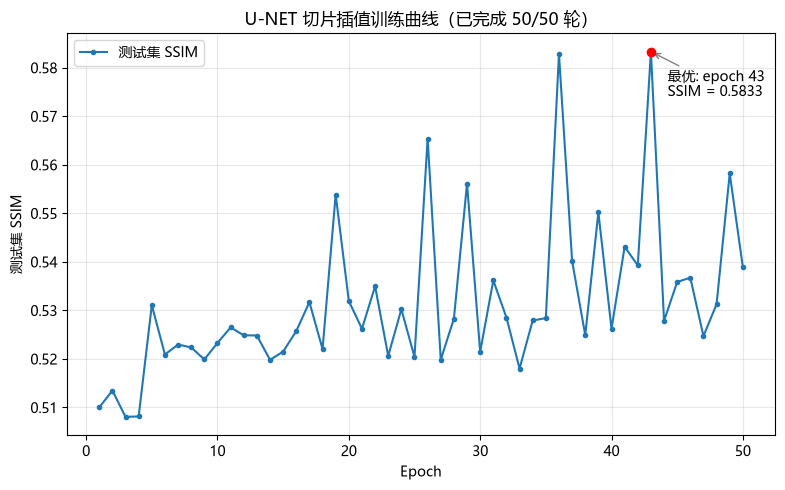

已完成 50/50 轮 | 首轮 SSIM 0.5100 | 最优 SSIM 0.5833（epoch 43） | 末轮 SSIM 0.5389


In [10]:
# 3. 可视化训练轮次-得分的走势
# 训练进行中也可随时运行本 cell —— 只画目前已完成的 epoch，可当作进度监视器
import matplotlib.pyplot as plt

# Windows 默认字体不含中文，切换到微软雅黑；顺带修复负号显示为方块的问题
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

assert len(ssim_history) > 0, 'ssim_history 为空：请至少完成 1 个 epoch 后再运行本 cell'

epochs_done = len(ssim_history)
best_idx = int(np.argmax(ssim_history))            # 最优 epoch（0 起算）
best_score = ssim_history[best_idx]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, epochs_done + 1), ssim_history,
        marker='o', markersize=3, linewidth=1.5,
        color='#1f77b4', label='测试集 SSIM')

# 标出历史最优点（SSIM 可能先升后降，最优不一定在最后一轮）
ax.scatter([best_idx + 1], [best_score], color='red', zorder=5)
ax.annotate(f'最优: epoch {best_idx + 1}\nSSIM = {best_score:.4f}',
            xy=(best_idx + 1, best_score),
            xytext=(12, -32), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_xlabel('Epoch')
ax.set_ylabel('测试集 SSIM')
ax.set_title(f'U-NET 切片插值训练曲线（已完成 {epochs_done}/{num_epochs} 轮）')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig('ssim_curve.png', dpi=150)             # 顺手存一份图，写报告可直接用
plt.show()

print(f'已完成 {epochs_done}/{num_epochs} 轮 | 首轮 SSIM {ssim_history[0]:.4f} '
      f'| 最优 SSIM {best_score:.4f}（epoch {best_idx + 1}） '
      f'| 末轮 SSIM {ssim_history[-1]:.4f}')